# Step 6 — Reinsurance Dependency Analysis

## 1. Data Preparation

In [ ]:
import pandas as pd
import numpy as np
import os

file_path = "Study Case for Univ Airlangga 2026 _Actuarial AXA (Sent 2026.05.26).xlsx"

# Load Raw Premium
df_prem_raw = pd.read_excel(file_path, sheet_name="Raw Premium", engine="openpyxl")
print("Raw Premium — shape:", df_prem_raw.shape)
print("Kolom:", list(df_prem_raw.columns))
display(df_prem_raw.head(3))

Raw Premium — shape: (390124, 12)
Kolom: ['COB', 'BRANCH_', 'CHANNEL_', 'PRODUCT_NAME', 'POLICY_NO', 'DT_INC', 'DT_END', 'GWP_IDR', 'RWP_IDR', 'GWC_IDR', 'RWC_IDR', 'SUM_INSURED']


,COB,BRANCH_,CHANNEL_,PRODUCT_NAME,POLICY_NO,DT_INC,DT_END,GWP_IDR,RWP_IDR,GWC_IDR,RWC_IDR,SUM_INSURED
0,COB 1,BRANCH J,CHANNEL D,PRODUCT0803,YY_00001100803012100001,2021-01-01,2021-07-01,37514.109589,0.0,0.000000,0.0,42500000.0
1,COB 1,BRANCH J,CHANNEL D,PRODUCT0803,YY_00001100803012100003,2021-01-01,2021-07-01,443738.955342,0.0,0.000000,0.0,502715000.0
2,COB 1,BRANCH J,CHANNEL D,PRODUCT0803,YY_00001020803022100007,2021-01-01,2021-08-01,452315.068493,0.0,45231.506849,0.0,437500000.0


In [ ]:
# Load Raw Claim
df_clm_raw = pd.read_excel(file_path, sheet_name="Raw Claim", engine="openpyxl")
print("Raw Claim — shape:", df_clm_raw.shape)
print("Kolom:", list(df_clm_raw.columns))
display(df_clm_raw.head(3))

Raw Claim — shape: (20087, 10)
Kolom: ['COB', 'BRANCH_', 'CHANNEL_', 'POLICY_NO', 'CLM_REF', 'DT_CLM', 'GRS_ST_IDR', 'RI_ST_IDR', 'GRS_OS_IDR', 'RI_OS_IDR']


,COB,BRANCH_,CHANNEL_,POLICY_NO,CLM_REF,DT_CLM,GRS_ST_IDR,RI_ST_IDR,GRS_OS_IDR,RI_OS_IDR
0,COB 1,BRANCH J,CHANNEL A,YY_00001110802022100001,XX_-110802042200001,2022-03-31,9000000.0,0.000000e+00,0.0,0.0
1,COB 1,BRANCH J,CHANNEL A,YY_00001110802022100001,XX_-110802072200001,2022-07-05,41198727.6,0.000000e+00,0.0,0.0
2,COB 1,BRANCH D,CHANNEL E,YY_00001050808072100002,XX_-050808122100013,2021-12-03,517752648.0,4.570579e+08,0.0,0.0


In [ ]:
# Aggregate by COB
df_prem = (
    df_prem_raw[["COB", "GWP_IDR", "RWP_IDR"]]
    .groupby("COB", as_index=False)
    .sum()
)

df_clm = (
    df_clm_raw[["COB", "GRS_ST_IDR", "GRS_OS_IDR", "RI_ST_IDR", "RI_OS_IDR"]]
    .groupby("COB", as_index=False)
    .sum()
)

# Merge
df = pd.merge(df_prem, df_clm, on="COB", how="outer").fillna(0)
df = df.sort_values("COB").reset_index(drop=True)

print("Tabel gabungan:")
display(df)

Tabel gabungan:


,COB,GWP_IDR,RWP_IDR,GRS_ST_IDR,GRS_OS_IDR,RI_ST_IDR,RI_OS_IDR
0,COB 1,1.196189e+11,6.993509e+10,2.383602e+10,2.330669e+09,1.245764e+10,9.251354e+08
1,COB 10,6.489250e+10,0.000000e+00,5.870562e+09,0.000000e+00,0.000000e+00,0.000000e+00
2,COB 2,2.094564e+10,5.180234e+04,5.434200e+09,0.000000e+00,0.000000e+00,0.000000e+00
3,COB 3,5.746793e+10,4.291977e+10,1.013741e+09,2.666729e+08,4.024577e+08,0.000000e+00
4,COB 4,3.192075e+11,5.620782e+10,2.853657e+11,5.988441e+09,1.060765e+10,5.285511e+08
5,COB 5,1.510009e+11,7.631139e+10,2.587012e+10,3.215560e+10,4.026824e+09,1.695108e+10
6,COB 6,4.206605e+11,5.476914e+09,3.840697e+11,0.000000e+00,4.310916e+08,0.000000e+00
7,COB 7,3.429804e+11,2.834829e+08,2.980840e+11,7.516174e+07,2.968974e+07,0.000000e+00
8,COB 8,2.515343e+11,4.482585e+07,3.782976e+10,0.000000e+00,0.000000e+00,0.000000e+00
9,COB 9,7.624109e+11,2.954189e+11,1.160237e+11,1.466753e+10,3.727448e+10,5.493881e+09


## 2. Calculate Metrics

In [ ]:
df["Net_Premium"]           = df["GWP_IDR"] - df["RWP_IDR"]
df["Gross_Incurred_Claim"]  = df["GRS_ST_IDR"] + df["GRS_OS_IDR"]
df["RI_Recovery"]           = df["RI_ST_IDR"]  + df["RI_OS_IDR"]

df["Cession_Rate"]    = df["RWP_IDR"]  / df["GWP_IDR"]
df["Recovery_Rate"]   = np.where(
    df["Gross_Incurred_Claim"] == 0,
    np.nan,
    df["RI_Recovery"] / df["Gross_Incurred_Claim"]
)
df["Retention_Ratio"] = df["Net_Premium"] / df["GWP_IDR"]
df["Gross_Loss_Ratio"]= df["Gross_Incurred_Claim"] / df["GWP_IDR"]
df["Net_Loss_Ratio"]  = np.where(
    df["Net_Premium"] == 0,
    np.nan,
    (df["Gross_Incurred_Claim"] - df["RI_Recovery"]) / df["Net_Premium"]
)

print("Metrics dihitung:")
display(df[["COB","Net_Premium","Gross_Incurred_Claim","RI_Recovery",
            "Cession_Rate","Recovery_Rate","Retention_Ratio",
            "Gross_Loss_Ratio","Net_Loss_Ratio"]])

Metrics dihitung:


,COB,Net_Premium,Gross_Incurred_Claim,RI_Recovery,Cession_Rate,Recovery_Rate,Retention_Ratio,Gross_Loss_Ratio,Net_Loss_Ratio
0,COB 1,4.968382e+10,2.616669e+10,1.338277e+10,0.584649,0.511443,0.415351,0.218750,0.257305
1,COB 10,6.489250e+10,5.870562e+09,0.000000e+00,0.000000,0.000000,1.000000,0.090466,0.090466
2,COB 2,2.094558e+10,5.434200e+09,0.000000e+00,0.000002,0.000000,0.999998,0.259443,0.259444
3,COB 3,1.454815e+10,1.280414e+09,4.024577e+08,0.746847,0.314318,0.253153,0.022281,0.060348
4,COB 4,2.629997e+11,2.913542e+11,1.113620e+10,0.176086,0.038222,0.823914,0.912742,1.065469
5,COB 5,7.468951e+10,5.802572e+10,2.097790e+10,0.505370,0.361528,0.494630,0.384274,0.496024
6,COB 6,4.151836e+11,3.840697e+11,4.310916e+08,0.013020,0.001122,0.986980,0.913016,0.924022
7,COB 7,3.426969e+11,2.981591e+11,2.968974e+07,0.000827,0.000100,0.999173,0.869318,0.869951
8,COB 8,2.514895e+11,3.782976e+10,0.000000e+00,0.000178,0.000000,0.999822,0.150396,0.150423
9,COB 9,4.669920e+11,1.306912e+11,4.276836e+10,0.387480,0.327247,0.612520,0.171418,0.188275


## 3. Segment Classification

In [ ]:
def classify_ri(row):
    cr = row["Cession_Rate"]
    rr = row["Recovery_Rate"]
    if cr > 0.3:
        if pd.notna(rr) and rr > 0.3:
            return "Effective"
        else:
            return "Inefficient"
    else:
        return "Low Dependency"

df["RI_Segment"] = df.apply(classify_ri, axis=1)
print("Klasifikasi Segmen:")
display(df[["COB", "Cession_Rate", "Recovery_Rate", "RI_Segment"]])

Klasifikasi Segmen:


,COB,Cession_Rate,Recovery_Rate,RI_Segment
0,COB 1,0.584649,0.511443,Effective
1,COB 10,0.000000,0.000000,Low Dependency
2,COB 2,0.000002,0.000000,Low Dependency
3,COB 3,0.746847,0.314318,Effective
4,COB 4,0.176086,0.038222,Low Dependency
5,COB 5,0.505370,0.361528,Effective
6,COB 6,0.013020,0.001122,Low Dependency
7,COB 7,0.000827,0.000100,Low Dependency
8,COB 8,0.000178,0.000000,Low Dependency
9,COB 9,0.387480,0.327247,Effective


## 4. Summary Table & Export

In [ ]:
pct_cols = ["Cession_Rate", "Recovery_Rate", "Retention_Ratio", "Gross_Loss_Ratio", "Net_Loss_Ratio"]
idr_cols = ["GWP_IDR", "RWP_IDR", "Net_Premium", "Gross_Incurred_Claim", "RI_Recovery"]

summary = df[["COB"] + idr_cols + pct_cols + ["RI_Segment"]].copy()

# Format untuk display
summary_display = summary.copy()
for c in pct_cols:
    summary_display[c] = summary_display[c].apply(
        lambda x: f"{x*100:.2f}%" if pd.notna(x) else "N/A"
    )
for c in idr_cols:
    summary_display[c] = summary_display[c].apply(lambda x: f"{x:,.0f}")

print("=" * 80)
print("STEP 6 — REINSURANCE DEPENDENCY ANALYSIS SUMMARY")
print("=" * 80)
display(summary_display)



STEP 6 — REINSURANCE DEPENDENCY ANALYSIS SUMMARY


,COB,GWP_IDR,RWP_IDR,Net_Premium,Gross_Incurred_Claim,RI_Recovery,Cession_Rate,Recovery_Rate,Retention_Ratio,Gross_Loss_Ratio,Net_Loss_Ratio,RI_Segment
0,COB 1,"119,618,908,447","69,935,087,728","49,683,820,719","26,166,689,951","13,382,773,781",58.46%,51.14%,41.54%,21.88%,25.73%,Effective
1,COB 10,"64,892,499,838",0,"64,892,499,838","5,870,562,106",0,0.00%,0.00%,100.00%,9.05%,9.05%,Low Dependency
2,COB 2,"20,945,635,570","51,802","20,945,583,768","5,434,200,000",0,0.00%,0.00%,100.00%,25.94%,25.94%,Low Dependency
3,COB 3,"57,467,926,068","42,919,774,252","14,548,151,816","1,280,414,195","402,457,725",74.68%,31.43%,25.32%,2.23%,6.03%,Effective
4,COB 4,"319,207,543,543","56,207,821,801","262,999,721,742","291,354,181,429","11,136,202,897",17.61%,3.82%,82.39%,91.27%,106.55%,Low Dependency
5,COB 5,"151,000,896,289","76,311,390,292","74,689,505,997","58,025,722,143","20,977,902,286",50.54%,36.15%,49.46%,38.43%,49.60%,Effective
6,COB 6,"420,660,523,861","5,476,913,501","415,183,610,360","384,069,692,454","431,091,612",1.30%,0.11%,98.70%,91.30%,92.40%,Low Dependency
7,COB 7,"342,980,363,837","283,482,869","342,696,880,968","298,159,145,749","29,689,740",0.08%,0.01%,99.92%,86.93%,87.00%,Low Dependency
8,COB 8,"251,534,301,544","44,825,850","251,489,475,694","37,829,764,118",0,0.02%,0.00%,99.98%,15.04%,15.04%,Low Dependency
9,COB 9,"762,410,875,051","295,418,868,386","466,992,006,665","130,691,192,885","42,768,357,219",38.75%,32.72%,61.25%,17.14%,18.83%,Effective


## 5. Interpretation

In [ ]:
print("=" * 80)
print("INTERPRETASI — STEP 6: REINSURANCE DEPENDENCY ANALYSIS")
print("=" * 80)

# Highest cession rate (most RI-dependent)
top_cession = summary.loc[summary["Cession_Rate"].idxmax()]
print(f"\n1. Ketergantungan Reasuransi Tertinggi:")
print(f"   COB '{top_cession['COB']}' memiliki Cession Rate tertinggi "
      f"({top_cession['Cession_Rate']*100:.2f}%), artinya proporsi premi yang "
      f"dicedkan ke reasuradur paling besar dibandingkan COB lainnya.")

# Segment breakdown
seg_counts = summary["RI_Segment"].value_counts()
print(f"\n2. Efektivitas Struktur Reasuransi per Segmen:")
for seg, cnt in seg_counts.items():
    cobs = ", ".join(summary.loc[summary["RI_Segment"] == seg, "COB"].tolist())
    print(f"   - {seg} ({cnt} COB): {cobs}")
print("   COB 'Effective' menunjukkan bahwa beban klaim yang dicedkan berhasil "
      "direcovery secara signifikan oleh reasuradur (Recovery Rate > 30%).")
print("   COB 'Inefficient' berarti cesi premi tinggi namun recovery klaim rendah "
      "— perlu evaluasi ulang struktur treaty/facultative.")
print("   COB 'Low Dependency' memiliki retensi tinggi; risiko lebih banyak ditanggung sendiri.")

# Gross vs Net Loss Ratio comparison
print(f"\n3. Perbandingan Gross Loss Ratio vs Net Loss Ratio:")
for _, row in summary.iterrows():
    glr = f"{row['Gross_Loss_Ratio']*100:.2f}%" if pd.notna(row['Gross_Loss_Ratio']) else "N/A"
    nlr = f"{row['Net_Loss_Ratio']*100:.2f}%"   if pd.notna(row['Net_Loss_Ratio'])   else "N/A"
    delta = ""
    if pd.notna(row['Net_Loss_Ratio']) and pd.notna(row['Gross_Loss_Ratio']):
        diff = (row['Net_Loss_Ratio'] - row['Gross_Loss_Ratio']) * 100
        direction = "↑ lebih tinggi" if diff > 0 else "↓ lebih rendah"
        delta = f"  → Net LR {direction} {abs(diff):.2f}pp dari Gross LR"
    print(f"   COB {row['COB']:>6}: Gross LR = {glr:>8}, Net LR = {nlr:>8}{delta}")

print("\n   Jika Net Loss Ratio > Gross Loss Ratio, reasuransi tidak menurunkan beban "
      "loss — bisa jadi karena premi neto terlalu kecil (cesi besar) atau recovery "
      "klaim minim. Sebaliknya, Net LR < Gross LR mengindikasikan reasuransi efektif "
      "menyerap risiko klaim.")

INTERPRETASI — STEP 6: REINSURANCE DEPENDENCY ANALYSIS

1. Ketergantungan Reasuransi Tertinggi:
   COB 'COB 3' memiliki Cession Rate tertinggi (74.68%), artinya proporsi premi yang dicedkan ke reasuradur paling besar dibandingkan COB lainnya.

2. Efektivitas Struktur Reasuransi per Segmen:
   - Low Dependency (6 COB): COB 10, COB 2, COB 4, COB 6, COB 7, COB 8
   - Effective (4 COB): COB 1, COB 3, COB 5, COB 9
   COB 'Effective' menunjukkan bahwa beban klaim yang dicedkan berhasil direcovery secara signifikan oleh reasuradur (Recovery Rate > 30%).
   COB 'Inefficient' berarti cesi premi tinggi namun recovery klaim rendah — perlu evaluasi ulang struktur treaty/facultative.
   COB 'Low Dependency' memiliki retensi tinggi; risiko lebih banyak ditanggung sendiri.

3. Perbandingan Gross Loss Ratio vs Net Loss Ratio:
   COB  COB 1: Gross LR =   21.88%, Net LR =   25.73%  → Net LR ↑ lebih tinggi 3.86pp dari Gross LR
   COB COB 10: Gross LR =    9.05%, Net LR =    9.05%  → Net LR ↓ lebih rendah

## 6. Narasi Interpretasi

Berdasarkan hasil analisis ketergantungan reasuransi pada Step 6, COB 3 tercatat memiliki Cession Rate tertinggi sebesar 74,68%, menandakan bahwa porsi premi yang dialihkan ke reasuradur sangat dominan, namun demikian COB ini tetap masuk kategori *Effective* karena Recovery Rate-nya mencapai 31,43% artinya reasuransi berhasil menyerap sebagian besar beban klaim yang dicedkan. Dari 10 COB yang dianalisis, hanya 4 COB (COB 1, COB 3, COB 5, dan COB 9) yang masuk segmen *Effective*, sementara 6 COB lainnya (COB 2, COB 4, COB 6, COB 7, COB 8, dan COB 10) tergolong *Low Dependency* karena retensi premi yang sangat tinggi dengan minim proteksi reasuransi. Kondisi ini patut diwaspadai khususnya pada COB 4 dan COB 6, yang masing-masing mencatatkan Gross Loss Ratio sebesar 91,27% dan 91,30% mendekati atau bahkan melampaui ambang batas profitabilitas  namun kedua COB tersebut justru memiliki Recovery Rate yang sangat rendah (masing-masing 3,82% dan 0,11%), sehingga Net Loss Ratio COB 4 bahkan mencapai 106,55%, melampaui premi neto yang diterima. Secara keseluruhan, hampir seluruh COB menunjukkan Net Loss Ratio yang lebih tinggi dari Gross Loss Ratio, yang mengindikasikan bahwa struktur reasuransi yang ada belum optimal dalam meredam beban kerugian bersih hal ini bisa disebabkan oleh premi retensi yang terlalu kecil akibat cesi besar, atau minimnya recovery klaim aktual dari reasuradur. Evaluasi menyeluruh terhadap desain program treaty dan facultative sangat disarankan, terutama untuk COB-COB dengan loss ratio tinggi namun proteksi reasuransi yang lemah.

## 7. Visualisasi

C:\Users\ijalg\AppData\Local\Temp\ipykernel_27232\897454868.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis = cm.get_cmap("viridis")


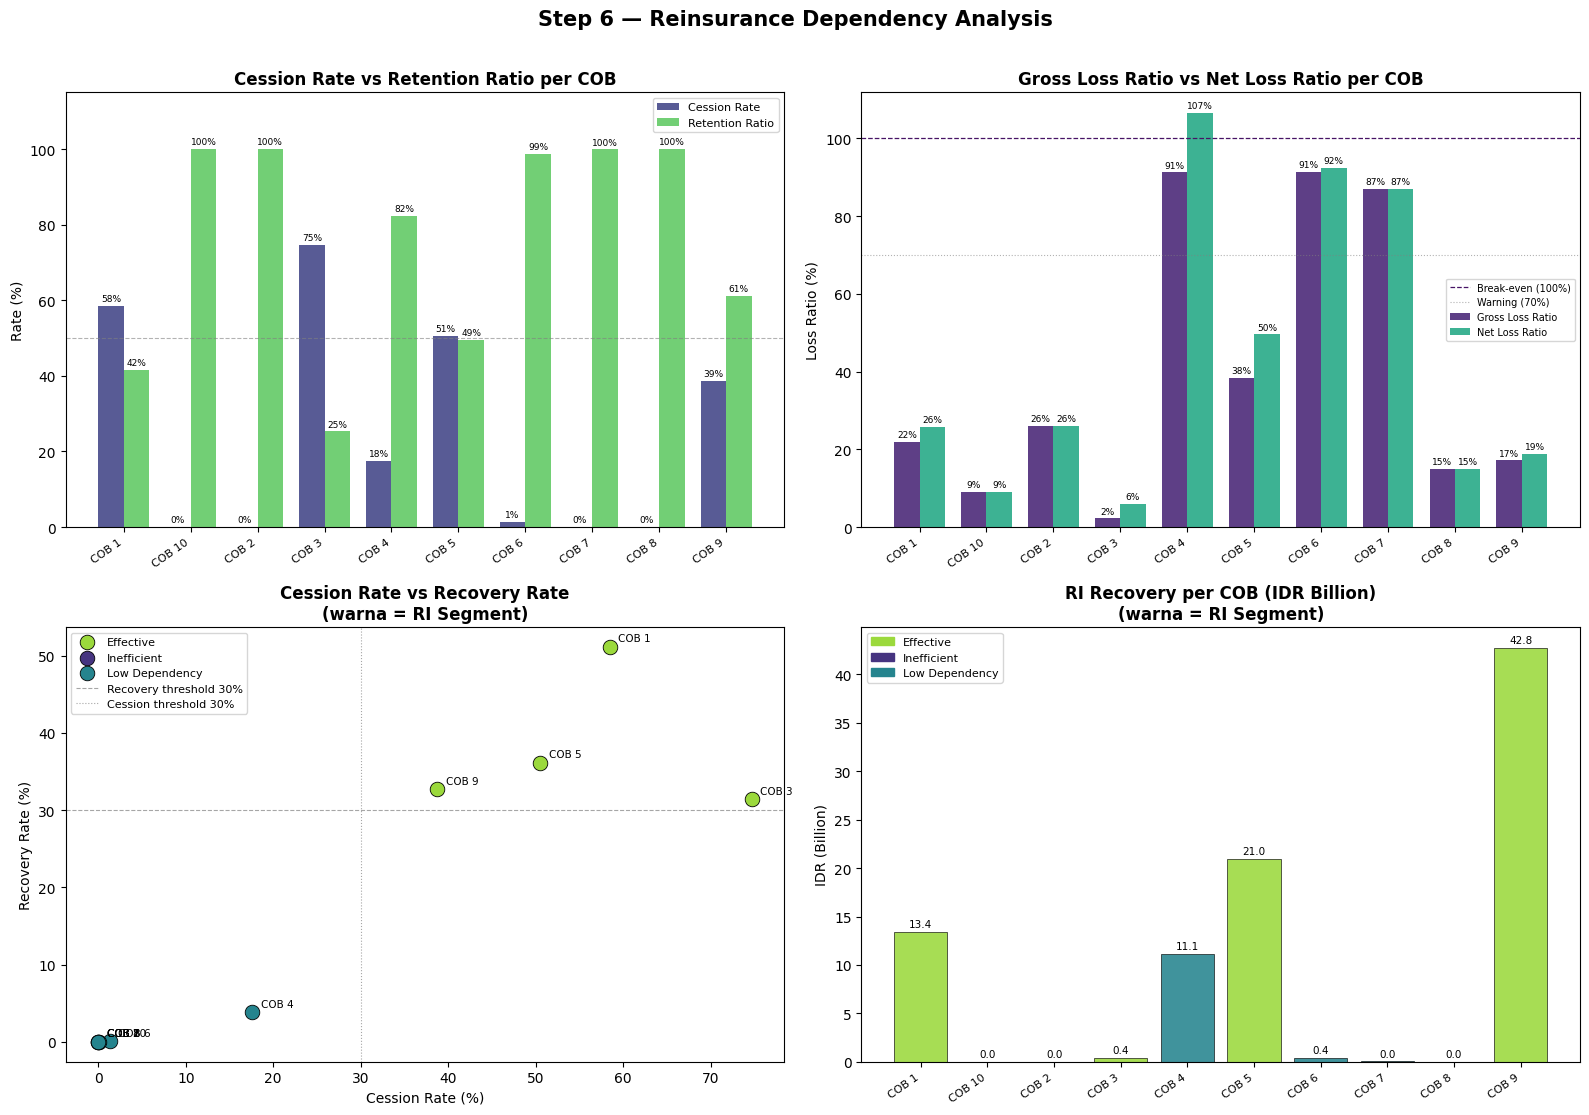

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import numpy as np

cobs = summary["COB"].tolist()
x = np.arange(len(cobs))
width = 0.38

viridis = cm.get_cmap("viridis")
seg_colors = {
    "Effective":      viridis(0.85),
    "Inefficient":    viridis(0.15),
    "Low Dependency": viridis(0.45),
}
bar_colors = [seg_colors[s] for s in summary["RI_Segment"]]

c_cession   = viridis(0.2)
c_retention = viridis(0.75)
c_glr       = viridis(0.1)
c_nlr       = viridis(0.6)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Step 6 — Reinsurance Dependency Analysis", fontsize=15, fontweight="bold", y=1.01)

# ── Chart 1: Cession Rate vs Retention Ratio ──────────────────────────────────
ax1 = axes[0, 0]
b1 = ax1.bar(x - width/2, summary["Cession_Rate"] * 100,    width, label="Cession Rate",    color=c_cession,   alpha=0.88)
b2 = ax1.bar(x + width/2, summary["Retention_Ratio"] * 100, width, label="Retention Ratio", color=c_retention, alpha=0.88)
ax1.set_title("Cession Rate vs Retention Ratio per COB", fontweight="bold")
ax1.set_xticks(x); ax1.set_xticklabels(cobs, rotation=35, ha="right", fontsize=8)
ax1.set_ylabel("Rate (%)")
ax1.set_ylim(0, 115)
ax1.axhline(50, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax1.legend(fontsize=8)
ax1.bar_label(b1, fmt="%.0f%%", fontsize=6.5, padding=2)
ax1.bar_label(b2, fmt="%.0f%%", fontsize=6.5, padding=2)

# ── Chart 2: Gross LR vs Net LR ───────────────────────────────────────────────
ax2 = axes[0, 1]
glr = summary["Gross_Loss_Ratio"] * 100
nlr = summary["Net_Loss_Ratio"] * 100
b3 = ax2.bar(x - width/2, glr, width, label="Gross Loss Ratio", color=c_glr, alpha=0.88)
b4 = ax2.bar(x + width/2, nlr, width, label="Net Loss Ratio",   color=c_nlr, alpha=0.88)
ax2.set_title("Gross Loss Ratio vs Net Loss Ratio per COB", fontweight="bold")
ax2.set_xticks(x); ax2.set_xticklabels(cobs, rotation=35, ha="right", fontsize=8)
ax2.set_ylabel("Loss Ratio (%)")
ax2.axhline(100, color=viridis(0.05), linestyle="--", linewidth=0.9, label="Break-even (100%)")
ax2.axhline(70,  color="gray",        linestyle=":",  linewidth=0.8, alpha=0.6, label="Warning (70%)")
ax2.legend(fontsize=7)
ax2.bar_label(b3, fmt="%.0f%%", fontsize=6.5, padding=2)
ax2.bar_label(b4, fmt="%.0f%%", fontsize=6.5, padding=2)

# ── Chart 3: Scatter — Cession Rate vs Recovery Rate ──────────────────────────
ax3 = axes[1, 0]
for seg, color in seg_colors.items():
    mask = summary["RI_Segment"] == seg
    ax3.scatter(
        summary.loc[mask, "Cession_Rate"] * 100,
        summary.loc[mask, "Recovery_Rate"] * 100,
        c=[color], label=seg, s=110, edgecolors="black", linewidths=0.6, zorder=3
    )
    for _, row in summary[mask].iterrows():
        ax3.annotate(row["COB"],
                     (row["Cession_Rate"]*100, row["Recovery_Rate"]*100),
                     textcoords="offset points", xytext=(6, 4), fontsize=7.5)

ax3.axhline(30, color="gray", linestyle="--", linewidth=0.8, alpha=0.7, label="Recovery threshold 30%")
ax3.axvline(30, color="gray", linestyle=":",  linewidth=0.8, alpha=0.7, label="Cession threshold 30%")
ax3.set_title("Cession Rate vs Recovery Rate\n(warna = RI Segment)", fontweight="bold")
ax3.set_xlabel("Cession Rate (%)"); ax3.set_ylabel("Recovery Rate (%)")
ax3.legend(fontsize=8)

# ── Chart 4: RI Recovery (absolute, IDR Billion) ──────────────────────────────
ax4 = axes[1, 1]
ri_bn = summary["RI_Recovery"] / 1e9
bars = ax4.bar(x, ri_bn, color=bar_colors, edgecolor="black", linewidth=0.5, alpha=0.88)
ax4.set_title("RI Recovery per COB (IDR Billion)\n(warna = RI Segment)", fontweight="bold")
ax4.set_xticks(x); ax4.set_xticklabels(cobs, rotation=35, ha="right", fontsize=8)
ax4.set_ylabel("IDR (Billion)")
ax4.bar_label(bars, fmt="%.1f", fontsize=7.5, padding=2)

patches = [mpatches.Patch(color=c, label=l) for l, c in seg_colors.items()]
ax4.legend(handles=patches, fontsize=8)

plt.tight_layout()
plt.show()

C:\Users\ijalg\AppData\Local\Temp\ipykernel_27232\3163775047.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis = cm.get_cmap("viridis")


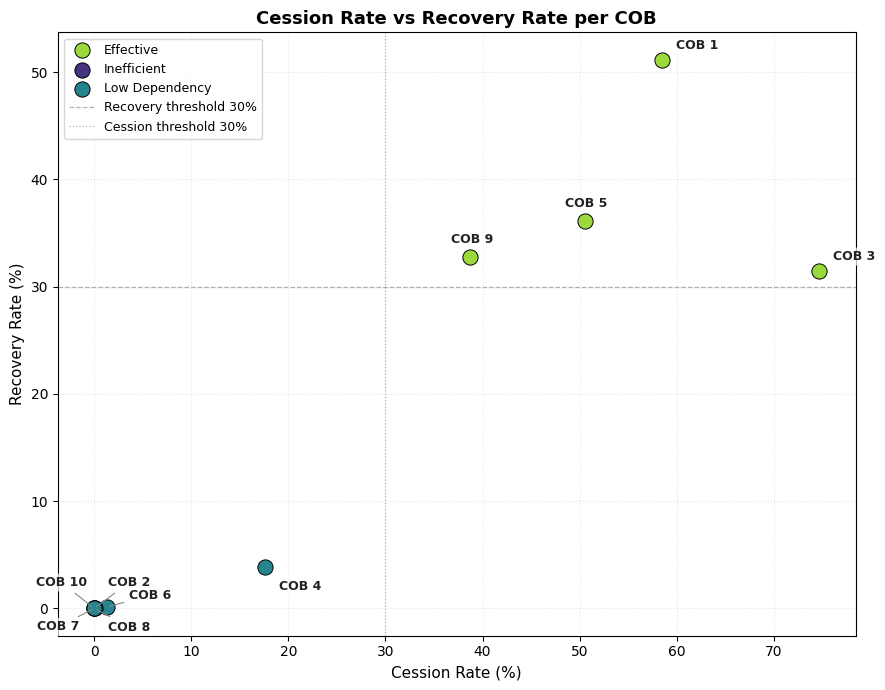

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

viridis = cm.get_cmap("viridis")
seg_colors = {
    "Effective":      viridis(0.85),
    "Inefficient":    viridis(0.15),
    "Low Dependency": viridis(0.45),
}

# Manual offset per COB — menghindari tumpang tindih di cluster dekat (0,0)
label_offsets = {
    "COB 1":  (10,   8),
    "COB 10": (-42,  16),
    "COB 2":  ( 10,  16),
    "COB 3":  ( 10,   8),
    "COB 4":  ( 10, -16),
    "COB 5":  (-14,  10),
    "COB 6":  ( 16,   6),
    "COB 7":  (-42, -16),
    "COB 8":  ( 10, -16),
    "COB 9":  (-14,  10),
}

# COB yang perlu panah (cluster padat)
use_arrow = {"COB 10", "COB 2", "COB 7", "COB 8", "COB 6"}

fig, ax = plt.subplots(figsize=(9, 7))

for seg, color in seg_colors.items():
    mask = summary["RI_Segment"] == seg
    ax.scatter(
        summary.loc[mask, "Cession_Rate"] * 100,
        summary.loc[mask, "Recovery_Rate"] * 100,
        c=[color], label=seg, s=120,
        edgecolors="black", linewidths=0.7, zorder=3
    )

for _, row in summary.iterrows():
    cob  = row["COB"]
    xy   = (row["Cession_Rate"] * 100, row["Recovery_Rate"] * 100)
    xytext = label_offsets.get(cob, (8, 6))

    arrow = dict(arrowstyle="-", color="#888888", lw=0.8) if cob in use_arrow else None

    ax.annotate(
        cob, xy=xy,
        textcoords="offset points", xytext=xytext,
        fontsize=9, fontweight="bold", color="#222222",
        arrowprops=arrow,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7)
    )

ax.axhline(30, color="gray", linestyle="--", linewidth=0.9, alpha=0.6, label="Recovery threshold 30%")
ax.axvline(30, color="gray", linestyle=":",  linewidth=0.9, alpha=0.6, label="Cession threshold 30%")
ax.set_title("Cession Rate vs Recovery Rate per COB", fontweight="bold", fontsize=13)
ax.set_xlabel("Cession Rate (%)", fontsize=11)
ax.set_ylabel("Recovery Rate (%)", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, linestyle=":", alpha=0.3)

plt.tight_layout()
plt.show()

C:\Users\ijalg\AppData\Local\Temp\ipykernel_27232\538876646.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis = cm.get_cmap("viridis")


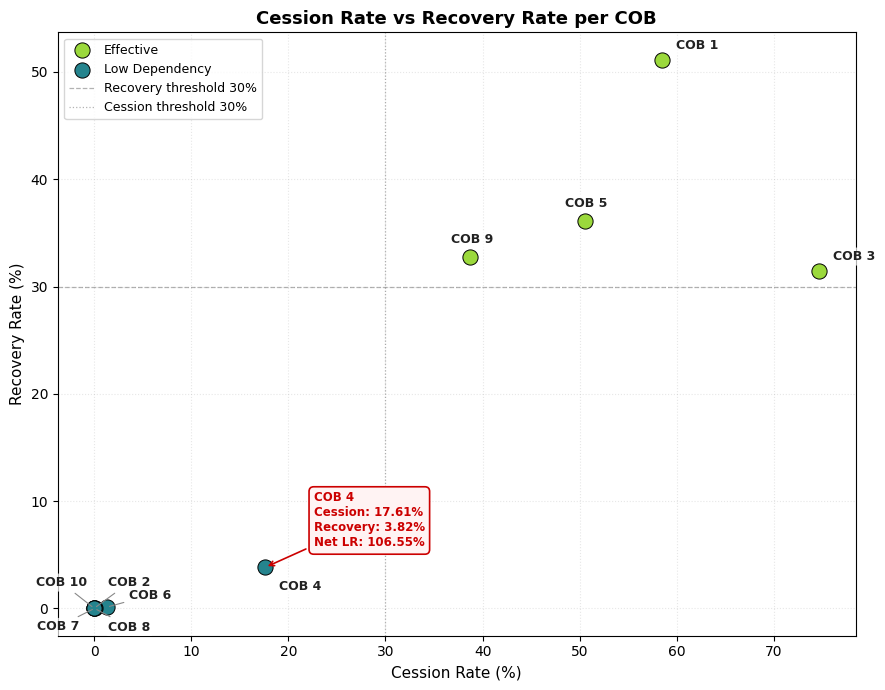

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

viridis = cm.get_cmap("viridis")
seg_colors = {
    "Effective":      viridis(0.85),
    "Inefficient":    viridis(0.15),
    "Low Dependency": viridis(0.45),
}

label_offsets = {
    "COB 1":  ( 10,   8),
    "COB 10": (-42,  16),
    "COB 2":  ( 10,  16),
    "COB 3":  ( 10,   8),
    "COB 4":  ( 10, -16),
    "COB 5":  (-14,  10),
    "COB 6":  ( 16,   6),
    "COB 7":  (-42, -16),
    "COB 8":  ( 10, -16),
    "COB 9":  (-14,  10),
}

use_arrow = {"COB 10", "COB 2", "COB 7", "COB 8", "COB 6"}

fig, ax = plt.subplots(figsize=(9, 7))

for seg, color in seg_colors.items():
    mask = summary["RI_Segment"] == seg
    ax.scatter(
        summary.loc[mask, "Cession_Rate"] * 100,
        summary.loc[mask, "Recovery_Rate"] * 100,
        c=[color], label=seg, s=120,
        edgecolors="black", linewidths=0.7, zorder=3
    )

for _, row in summary.iterrows():
    cob    = row["COB"]
    xy     = (row["Cession_Rate"] * 100, row["Recovery_Rate"] * 100)
    xytext = label_offsets.get(cob, (8, 6))
    arrow  = dict(arrowstyle="-", color="#888888", lw=0.8) if cob in use_arrow else None

    ax.annotate(
        cob, xy=xy,
        textcoords="offset points", xytext=xytext,
        fontsize=9, fontweight="bold", color="#222222",
        arrowprops=arrow,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7)
    )

# ── Callout Box COB 4 ─────────────────────────────────────────────────────────
cob4 = summary[summary["COB"] == "COB 4"].iloc[0]
ax.annotate(
    "COB 4\nCession: 17.61%\nRecovery: 3.82%\nNet LR: 106.55%",
    xy=(cob4["Cession_Rate"] * 100, cob4["Recovery_Rate"] * 100),
    xytext=(35, 15),
    textcoords="offset points",
    fontsize=8.5,
    color="#cc0000",
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.4", fc="#fff3f3", ec="#cc0000", lw=1.2),
    arrowprops=dict(arrowstyle="->", color="#cc0000", lw=1.2),
)

ax.axhline(30, color="gray", linestyle="--", linewidth=0.9, alpha=0.6, label="Recovery threshold 30%")
ax.axvline(30, color="gray", linestyle=":",  linewidth=0.9, alpha=0.6, label="Cession threshold 30%")
ax.set_title("Cession Rate vs Recovery Rate per COB", fontweight="bold", fontsize=13)
ax.set_xlabel("Cession Rate (%)", fontsize=11)
ax.set_ylabel("Recovery Rate (%)", fontsize=11)
ax.grid(True, linestyle=":", alpha=0.3)

# ── Filter legend — hapus Inefficient karena tidak ada di data ────────────────
handles, labels = ax.get_legend_handles_labels()
filtered = [
    (h, l) for h, l in zip(handles, labels)
    if l in summary["RI_Segment"].unique() or "threshold" in l
]
ax.legend([f[0] for f in filtered], [f[1] for f in filtered], fontsize=9)

plt.tight_layout()
plt.savefig("scatter_reinsurance.png", dpi=150, bbox_inches="tight")
plt.show()